In [1]:
# --- Portable bootstrap: locate scripts/ from any working directory ---
import sys
from pathlib import Path

def _find_scripts_dir():
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for cand in (base / "scripts", base,
                     *sorted(base.glob("*/scripts")), *sorted(base.glob("*/*/scripts"))):
            if (cand / "project_paths.py").is_file():
                return cand
    raise FileNotFoundError(
        "scripts/project_paths.py not found. Open this notebook from inside the "
        "cloned repository, or point the kernel's working directory at it."
    )

sys.path.insert(0, str(_find_scripts_dir()))
from project_config import *

import numpy as np, librosa, librosa.display, matplotlib.pyplot as plt


In [2]:
# --- Clips used for the audio-representation figures -------------------------
# Each clip is loaded into its own dict, so the figures below share no mutable
# state: they can be re-run in any order without silently plotting one subject's
# audio under another's label.
CLIPS = {
    "HC":  ("02030002", "04"),      # PHQ-9 = 0,   21.3 s
    "MDD": ("02010001", "17"),      # PHQ-9 = 21,  22.0 s
}
N_FFT, HOP = 1024, 256

def load_clip(subject, recording):
    """Load one recording and precompute everything both figures need."""
    wav = RESAMPLED_DIR / subject / f"{recording}_resampled.wav"
    sig, sr = librosa.load(wav, sr=None)
    S = np.abs(librosa.stft(sig, n_fft=N_FFT, hop_length=HOP))
    # pyin is the slow step (a few seconds per clip) -- done once, here
    f0, voiced, _ = librosa.pyin(sig, fmin=60, fmax=400, sr=sr,
                                 frame_length=N_FFT, hop_length=HOP)
    return dict(
        subject=subject, recording=recording, wav=wav, sig=sig, sr=sr,
        S=S, f0=f0, voiced=voiced,
        freqs=librosa.fft_frequencies(sr=sr, n_fft=N_FFT),
        times=librosa.frames_to_time(np.arange(S.shape[1]), sr=sr, hop_length=HOP),
    )

clips = {g: load_clip(*v) for g, v in CLIPS.items()}
for g, c in clips.items():
    print(f"{g:4s} {c['subject']}/{c['wav'].name}  {len(c['sig'])/c['sr']:5.1f}s  "
          f"{c['S'].shape[1]:4d} frames  {int(np.nansum(c['voiced'])):4d} voiced")


HC   02030002/04_resampled.wav   21.3s  1334 frames   576 voiced
MDD  02010001/17_resampled.wav   22.0s  1376 frames   769 voiced


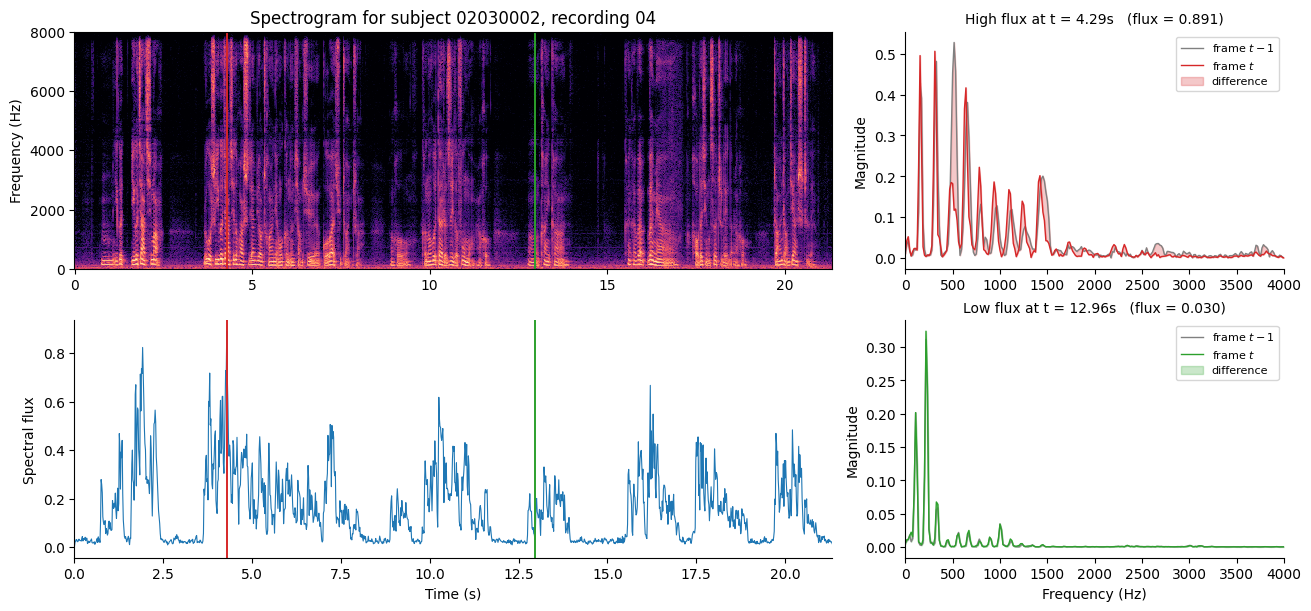

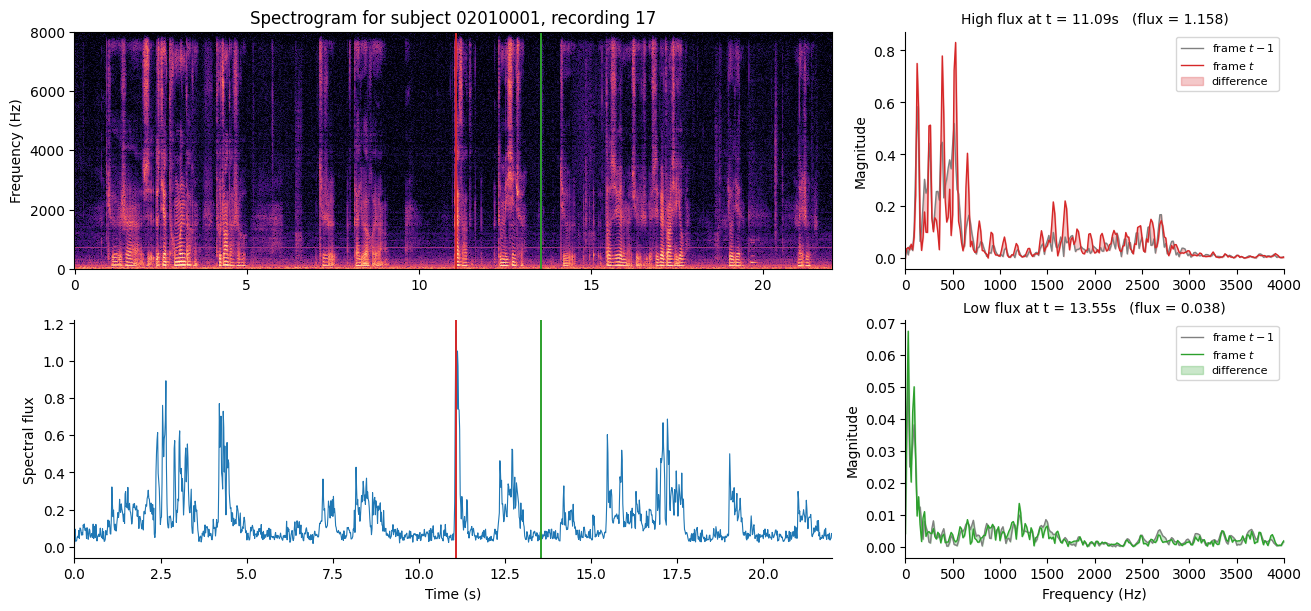

In [3]:
# What spectral flux measures: the frame-to-frame change in the magnitude spectrum.
# Left: where in the recording the spectrum changes fast. Right: the two
# consecutive spectra being compared, at a high-flux and a low-flux frame.
def flux_figure(c, group):
    S, freqs, times, sr = c["S"], c["freqs"], c["times"], c["sr"]
    Sn   = S / (S.max() + 1e-12)
    flux = np.concatenate([[0.0], np.sqrt((np.diff(Sn, axis=1) ** 2).sum(axis=0))])

    energy = Sn.sum(axis=0)
    cand   = np.where((energy > np.median(energy)) & (np.arange(len(energy)) > 0))[0]
    t_hi, t_lo = cand[np.argmax(flux[cand])], cand[np.argmin(flux[cand])]

    fig = plt.figure(figsize=(13, 6), layout="constrained")
    gs  = fig.add_gridspec(2, 2, width_ratios=[2, 1])
    ax_s, ax_f = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])
    ax_hi, ax_lo = fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])

    librosa.display.specshow(librosa.amplitude_to_db(Sn, ref=np.max), sr=sr, hop_length=HOP,
                             x_axis="time", y_axis="hz", ax=ax_s, cmap="magma")
    ax_s.set_ylabel("Frequency (Hz)"); ax_s.set_xlabel("")
    ax_s.set_title(f"Spectrogram for subject {c['subject']}, recording {c['recording']}")

    ax_f.plot(times, flux, lw=0.8, color="#1f77b4")
    ax_f.set_xlim(times[0], times[-1])
    ax_f.set_xlabel("Time (s)"); ax_f.set_ylabel("Spectral flux")
    ax_f.spines[["top", "right"]].set_visible(False)

    for t_idx, color in [(t_hi, "#d62728"), (t_lo, "#2ca02c")]:
        ax_s.axvline(times[t_idx], color=color, lw=1.4)
        ax_f.axvline(times[t_idx], color=color, lw=1.4)

    for ax, t_idx, label, color in [(ax_hi, t_hi, "High flux", "#d62728"),
                                    (ax_lo, t_lo, "Low flux",  "#2ca02c")]:
        prev, cur = Sn[:, t_idx - 1], Sn[:, t_idx]
        ax.plot(freqs, prev, lw=1, color="gray", label="frame $t-1$")
        ax.plot(freqs, cur,  lw=1, color=color,  label="frame $t$")
        ax.fill_between(freqs, prev, cur, color=color, alpha=0.25, label="difference")
        ax.set_xlim(0, 4000)
        ax.set_title(f"{label} at t = {times[t_idx]:.2f}s   (flux = {flux[t_idx]:.3f})", fontsize=10)
        ax.set_ylabel("Magnitude"); ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
    ax_lo.set_xlabel("Frequency (Hz)")

    plt.savefig(PLOTS_DIR / f"spectral_flux_explained_{c['subject']}_{c['recording']}.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    return flux

flux_by_group = {g: flux_figure(c, g) for g, c in clips.items()}


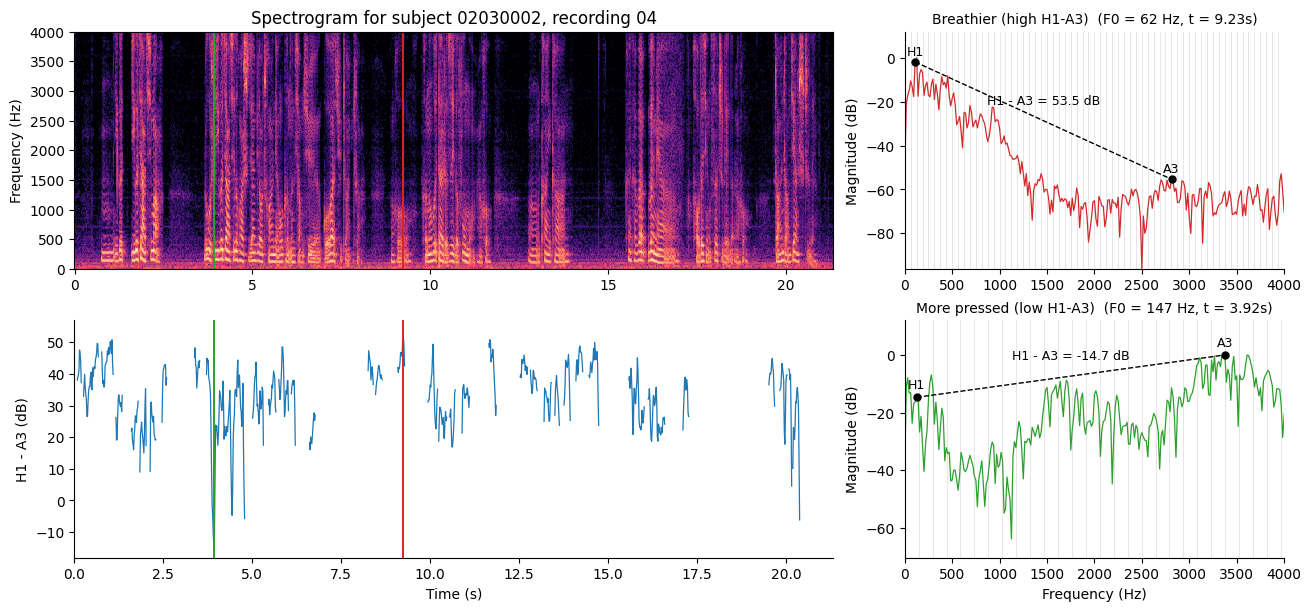

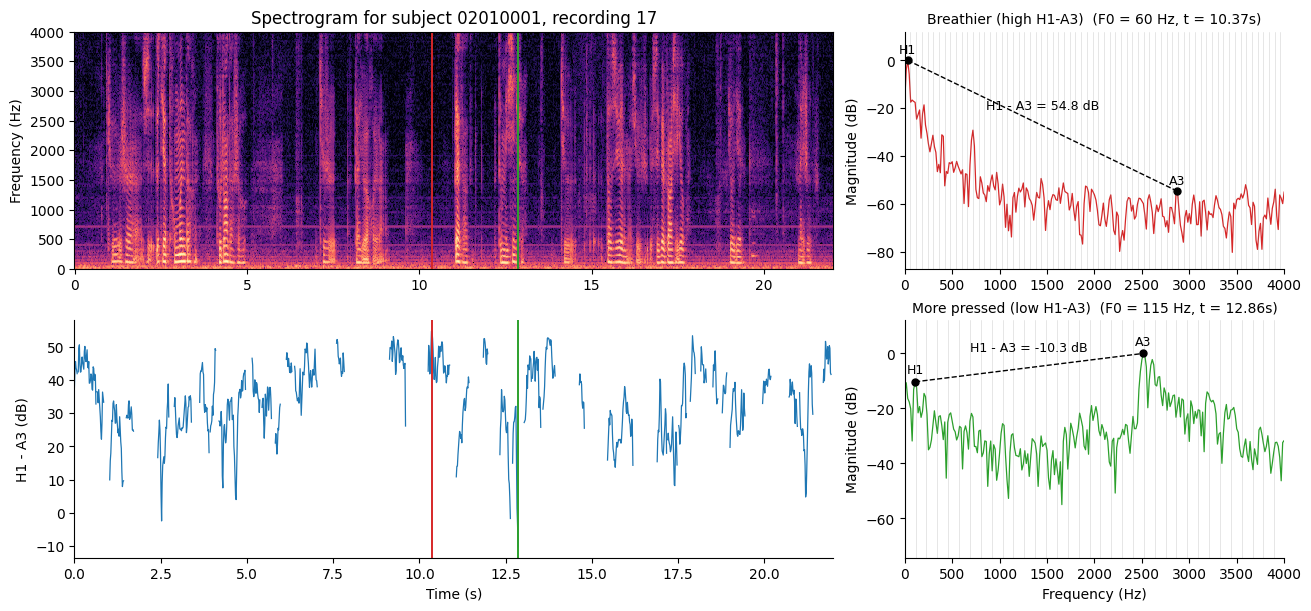

In [4]:
# What logRelF0-H1-A3 measures: spectral tilt: how much weaker the F3-region
# harmonic is than the fundamental. High = breathy, low = pressed.
F3_BAND = (2000, 3500)          # typical F3 region for adult speech

def h1a3_series(c, f3_band=F3_BAND):
    """Per-frame H1-A3 in dB, plus the frequencies of the H1 and A3 peaks."""
    S, freqs, f0, voiced = c["S"], c["freqs"], c["f0"], c["voiced"]

    def peak_near(spec, f_target, tol=60):
        band = (freqs > f_target - tol) & (freqs < f_target + tol)
        return (spec[band].max(), freqs[band][spec[band].argmax()]) if band.any() else (np.nan, np.nan)

    def band_peak(spec, lo, hi):
        band = (freqs > lo) & (freqs < hi)
        i = spec[band].argmax()
        return spec[band][i], freqs[band][i]

    n = min(S.shape[1], len(f0))
    h1a3 = np.full(n, np.nan); h1f = np.full(n, np.nan); a3f = np.full(n, np.nan)
    for t in range(n):
        if not voiced[t] or not np.isfinite(f0[t]):
            continue
        h1, fh1 = peak_near(S[:, t], f0[t])
        a3, fa3 = band_peak(S[:, t], *f3_band)
        h1a3[t] = 20 * np.log10((h1 + 1e-12) / (a3 + 1e-12))
        h1f[t], a3f[t] = fh1, fa3
    return h1a3, h1f, a3f

def h1a3_figure(c, group):
    S, freqs, times, sr, f0 = c["S"], c["freqs"], c["times"], c["sr"], c["f0"]
    h1a3, h1f, a3f = h1a3_series(c)
    n = len(h1a3)
    t_breathy, t_pressed = int(np.nanargmax(h1a3)), int(np.nanargmin(h1a3))

    fig = plt.figure(figsize=(13, 6), layout="constrained")
    gs  = fig.add_gridspec(2, 2, width_ratios=[2, 1])
    ax_s, ax_t = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])
    ax_b, ax_p = fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])

    librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max), sr=sr, hop_length=HOP,
                             x_axis="time", y_axis="hz", ax=ax_s, cmap="magma")
    ax_s.set_ylim(0, 4000); ax_s.set_ylabel("Frequency (Hz)"); ax_s.set_xlabel("")
    ax_s.set_title(f"Spectrogram for subject {c['subject']}, recording {c['recording']}")

    ax_t.plot(times[:n], h1a3, lw=0.9, color="#1f77b4")
    ax_t.set_xlim(times[0], times[n - 1])
    ax_t.set_xlabel("Time (s)"); ax_t.set_ylabel("H1 - A3 (dB)")
    ax_t.spines[["top", "right"]].set_visible(False)

    for t_idx, color in [(t_breathy, "#d62728"), (t_pressed, "#2ca02c")]:
        ax_s.axvline(times[t_idx], color=color, lw=1.4)
        ax_t.axvline(times[t_idx], color=color, lw=1.4)

    for ax, t_idx, label, color in [(ax_b, t_breathy, "Breathier (high H1-A3)", "#d62728"),
                                    (ax_p, t_pressed, "More pressed (low H1-A3)", "#2ca02c")]:
        db = 20 * np.log10(S[:, t_idx] + 1e-12); db -= db.max()
        ax.plot(freqs, db, lw=0.9, color=color)
        for k in range(1, int(4000 / f0[t_idx]) + 1):
            ax.axvline(k * f0[t_idx], color="gray", lw=0.4, alpha=0.35)
        yh = db[np.argmin(abs(freqs - h1f[t_idx]))]
        ya = db[np.argmin(abs(freqs - a3f[t_idx]))]
        ax.plot([h1f[t_idx], a3f[t_idx]], [yh, ya], "o--", color="black", lw=1, ms=5)
        ax.annotate(f"H1 - A3 = {h1a3[t_idx]:.1f} dB",
                    xy=((h1f[t_idx] + a3f[t_idx]) / 2, (yh + ya) / 2),
                    xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9)
        ax.text(h1f[t_idx], yh + 3, "H1", ha="center", fontsize=9)
        ax.text(a3f[t_idx], ya + 3, "A3", ha="center", fontsize=9)
        ax.set_xlim(0, 4000); ax.set_ylim(db.min(), 12)
        ax.set_title(f"{label}  (F0 = {f0[t_idx]:.0f} Hz, t = {times[t_idx]:.2f}s)", fontsize=10)
        ax.set_ylabel("Magnitude (dB)")
        ax.spines[["top", "right"]].set_visible(False)
    ax_p.set_xlabel("Frequency (Hz)")

    plt.savefig(PLOTS_DIR / f"h1a3_explained_{c['subject']}_{c['recording']}.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    return h1a3

h1a3_by_group = {g: h1a3_figure(c, g) for g, c in clips.items()}
